In [ ]:
#Unet Architecture
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, MaxPooling2D, Conv2DTranspose, Concatenate, Input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import l2

def conv_block(inputs, num_filters, reg_strength=5e-5):

  x = Conv2D(num_filters, 3, padding="same",kernel_regularizer=l2(reg_strength))(inputs)
  x = BatchNormalization()(x)
  x = Activation("relu")(x)

  x = Conv2D(num_filters, 3, padding="same",kernel_regularizer=l2(reg_strength))(x)
  x = BatchNormalization()(x)
  x = Activation("relu")(x)

  return x

def encoder_block(inputs, num_filters):
  x = conv_block(inputs, num_filters,1e-4)
  p = MaxPooling2D((2, 2))(x)
  return x, p

def decoder_block(inputs,skip_features, num_filters):

  x = Conv2DTranspose(num_filters, 2, strides=2, padding="same")(inputs)
  x = Concatenate()([x, skip_features])
  x = conv_block(x, num_filters,5e-5)
  return x

def build_unet(input_shape):
  inputs = Input(input_shape)
#encoder 1
  e1,p1 = encoder_block(inputs, 64)
#encoder 2
  e2,p2 = encoder_block(p1, 128)
#encoder 3
  e3,p3 = encoder_block(p2, 256)
#encoder 4
  e4,p4 = encoder_block(p3, 512)


#bottleneck
  b1 = conv_block(p4, 1024)
  b1=Dropout(0.3)(b1)
#decoder 1
  d1 = decoder_block(b1, e4, 512)
#decoder 2
  d2 = decoder_block(d1, e3, 256)
#decoder 3
  d3 = decoder_block(d2, e2, 256)
#decoder 4
  d4 = decoder_block(d3, e1, 256)


#output block
  outputs = Conv2D(1, 1, padding="same", activation="sigmoid")(d4)
  model = Model(inputs, outputs, name="U-Net")
  return model

# if __name__ == "__main__":
#     input_shape = (256, 256, 3)
#     model = build_unet(input_shape)
#     model.summary()

In [ ]:
# Metrics
from tensorflow.keras import backend as K

smooth = 1e-15
#Dice_coefficient
def dice_coeff(y_true, y_pred):
    y_true = tf.keras.layers.Flatten()(y_true)
    y_pred = tf.keras.layers.Flatten()(y_pred)
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth)


#Dice loss
def dice_loss(y_true, y_pred):
    return 1.0 - dice_coeff(y_true, y_pred)

#precision
def precision(y_true, y_pred):
    true_positives = tf.reduce_sum(tf.round(y_true * y_pred))
    predicted_positives = tf.reduce_sum(tf.round(y_pred))
    return true_positives / (predicted_positives + tf.keras.backend.epsilon())

#recall
def recall(y_true, y_pred):
    true_positives = tf.reduce_sum(tf.round(y_true * y_pred))
    possible_positives = tf.reduce_sum(tf.round(y_true))
    return true_positives / (possible_positives + tf.keras.backend.epsilon())

#f1 score
def f1_score(y_true, y_pred):
    p = precision(y_true, y_pred)
    r = recall(y_true, y_pred)
    return 2 * p * r / (p + r + tf.keras.backend.epsilon())

In [ ]:
import os
import cv2
import numpy as np
import glob
from sklearn.model_selection import train_test_split
import tensorflow as tf


#global variables
H=256
W=256

#create a directory

def create_directory(directory_path):
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)


def load_dataset(path,split=0.2):
  image=sorted(glob.glob(os.path.join(path,'immature_image','*.png')))
  mask=sorted(glob.glob(os.path.join(path,'immature_segmented','*.png')))

  split_size=int(len(image)*split)

  train_x,valid_x=train_test_split(image,test_size=split_size,random_state=42)
  train_y,valid_y=train_test_split(mask,test_size=split_size,random_state=42)

  train_x,test_x=train_test_split(train_x,test_size=0.1,random_state=42)
  train_y,test_y=train_test_split(train_y,test_size=0.1,random_state=42)

  return (train_x,train_y),(test_x,test_y),(valid_x,valid_y)

def read_image(path):
  path=path.decode()
  img=cv2.imread(path,cv2.IMREAD_COLOR)
  img=cv2.resize(img,(W,H))
  img=img/255.0
  img=img.astype(np.float32)
  return img

def read_mask(path):
  path=path.decode()
  mask=cv2.imread(path,cv2.IMREAD_GRAYSCALE)
  mask=cv2.resize(mask,(W,H))
  mask=mask/255.0
  mask=mask.astype(np.float32)
  mask=np.expand_dims(mask,axis=-1)
  return mask

def tf_parse(x,y):
  def _parse(x,y):
    x=read_image(x)
    y=read_mask(y)
    return x,y

  x,y=tf.numpy_function(_parse,[x,y],[tf.float32,tf.float32])
  x.set_shape([H,W,3])
  y.set_shape([H,W,1])
  return x,y

def tf_dataset(x,y,batch_size=2):
  dataset=tf.data.Dataset.from_tensor_slices((x,y))
  dataset=dataset.map(tf_parse)
  dataset=dataset.batch(batch_size)
  dataset=dataset.prefetch(10)
  return dataset

def save_results(image, mask, y_pred, save_image_path):
    # mask = np.expand_dims(mask, axis=-1)
    # mask = np.concatenate([mask, mask, mask], axis=-1)

    y_pred = np.expand_dims(y_pred, axis=-1)
    y_pred = np.concatenate([y_pred, y_pred, y_pred], axis=-1)
    y_pred = y_pred * 255

    # line = np.ones((H, 10, 3)) * 255

   # cat_images = np.concatenate([image, line, mask, line, y_pred], axis=1)
    cv2.imwrite(save_image_path, y_pred)


# create_directory('/content/drive/My Drive/Dataset')



# print(f'Train:{len(train_x)} - {len(train_y)}')
# print(f'Test:{len(test_x)} - {len(test_y)}')
# print(f'Valid:{len(valid_x)} - {len(valid_y)}')

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, ReduceLROnPlateau, EarlyStopping, TensorBoard
from tensorflow.keras.optimizers import Adam
#seeding
np.random.seed(42)
tf.random.set_seed(42)
# Load data
datapath='/content/drive/MyDrive/managed minor'
(train_x,train_y),(test_x,test_y),(valid_x,valid_y)=load_dataset(datapath)

#hyper parameters
learning_rate=2e-4
batch_size=8 #or 8
no_of_epochs=50

#Paths for saving model and metrics
model_path = os.path.join("/content/drive/MyDrive/Dataset", "model_data_bs_8.keras")
csv_path = os.path.join("/content/drive/MyDrive/Dataset", "model_metrics_bs_8.csv")

#Set train and validation data
train_dataset=tf_dataset(train_x,train_y,batch_size)
valid_dataset=tf_dataset(valid_x,valid_y,batch_size)

#call unet model and run model

model = build_unet((H, W, 3))
model.compile(loss=dice_loss, optimizer=Adam(learning_rate), metrics=[dice_coeff,precision,recall,f1_score])

callbacks = [ ModelCheckpoint(model_path, verbose=1, save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-8, verbose=1),
    CSVLogger(csv_path),
    EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=False),
]

history=model.fit(train_dataset,
    epochs=no_of_epochs,
    validation_data=valid_dataset,
    callbacks=callbacks
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_coeff: 0.4085 - f1_score: 0.4492 - loss: 0.5914 - precision: 0.3253 - recall: 0.9193
Epoch 1: val_loss improved from inf to 0.86962, saving model to /content/drive/MyDrive/Dataset/model_data_bs_8.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - dice_coeff: 0.4157 - f1_score: 0.4571 - loss: 0.5841 - precision: 0.3335 - recall: 0.9201 - val_dice_coeff: 0.1265 - val_f1_score: 0.0000e+00 - val_loss: 0.8696 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 2.0000e-04
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - dice_coeff: 0.7700 - f1_score: 0.8141 - loss: 0.2295 - precision: 0.8071 - recall: 0.8479
Epoch 2: val_loss did not improve from 0.86962
20/20 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - dice_coeff: 0.7702 - f1_score: 0.8139 - loss: 0.2290 - precision: 0.8054 - recall: 0.8495 - val_dice_coeff: 0.1155 - val_f1_score: 0.0000e+00 - val_loss: 0.8812 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate:

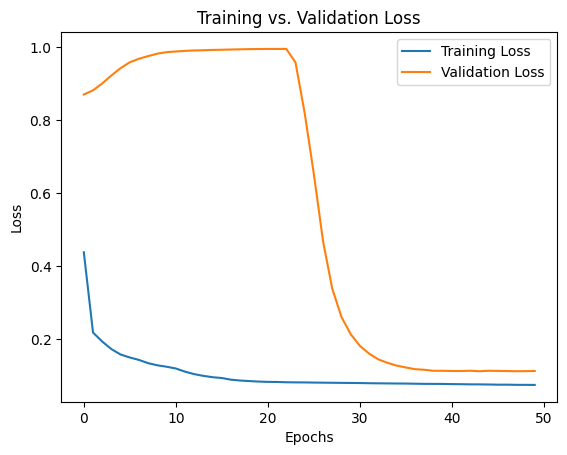

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs. Validation Loss')
plt.show()

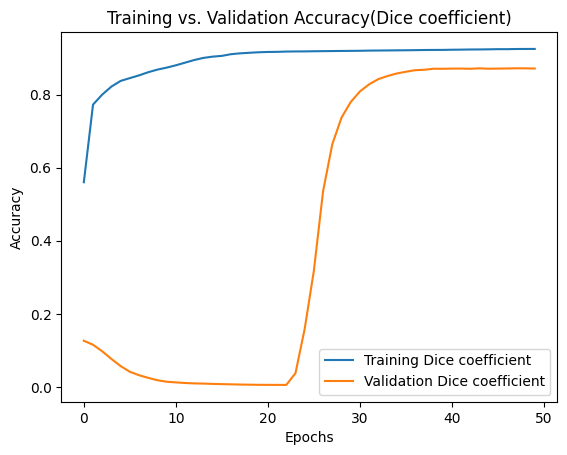

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.plot(history.history['dice_coeff'], label='Training Dice coefficient')
plt.plot(history.history['val_dice_coeff'], label='Validation Dice coefficient')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs. Validation Accuracy(Dice coefficient)')
plt.show()

In [ ]:
# Save the entire model
model.save("/content/drive/MyDrive/model_save/Unet_model_bs_8.keras")

In [ ]:
from tqdm import tqdm
from tensorflow.keras.utils import CustomObjectScope
import numpy as np
import cv2
import os
# from sklearn.metrics import f1_score, jaccard_score, precision_score, recall_score

import pandas as pd
#seeding
np.random.seed(42)
tf.random.set_seed(42)

# Load data
datapath='/content/drive/MyDrive/managed minor'
(train_x,train_y),(test_x,test_y),(valid_x,valid_y)=load_dataset(datapath)

#create directory for  saving prediction
create_directory('/content/drive/MyDrive/Dataset/results_bs_8')

#load model
with CustomObjectScope({"dice_coeff": dice_coeff, "dice_loss": dice_loss,"precision":precision,"recall":recall,"f1_score":f1_score}):
  model = tf.keras.models.load_model(os.path.join("/content/drive/MyDrive/model_save", "Unet_model_bs_8.keras"))


#prediction from model
SCORE = []
x=test_x
for x, y in tqdm(zip(test_x, test_y), total=len(test_y)):
  name = 'test_' + x.split("/")[-1]

  image = cv2.imread(x, cv2.IMREAD_COLOR) ## [H, w, 3]
  image = cv2.resize(image, (256,256))       ## [H, w, 3]
  x = image/255.0                         ## [H, w, 3]
  x = np.expand_dims(x, axis=0)           ## [1, H, w, 3]
  x = x.astype(np.float32)

  """ Reading the mask """
  mask = cv2.imread(y, cv2.IMREAD_GRAYSCALE)
  mask = cv2.resize(mask, (W, H))
  mask = mask/255.0
  mask = np.expand_dims(mask, axis=0)
  mask = np.expand_dims(mask, axis=-1)                     ## [1,H, w, 1]
  mask= mask.astype(np.float32)


  """ Prediction """
  # y_pred = model.predict(x, verbose=0)[0]
  # y_pred = np.squeeze(y_pred, axis=-1)
  # y_pred = y_pred >= 0.5
  # y_pred = y_pred.astype(np.int32)

  #save prediction
  # save_image_path = os.path.join("/content/drive/My Drive/Dataset/results_bs_8", name)
  # save_results(image, mask, y_pred, save_image_path)

  # mask = mask/255.0
  # mask = (mask > 0.5).astype(np.int32).flatten()
  # y_pred = y_pred.flatten()
  if isinstance(x, tf.Tensor):
        x = x.numpy()
  if isinstance(mask, tf.Tensor):
        mask = mask.numpy()

  loss, dice_coeff_val, precision_val, recall_val, f1_score_val = model.evaluate(x, mask, batch_size=1) # use input_image , Change the variable name
  SCORE.append([name, f1_score_val, dice_coeff_val, recall_val, precision_val, loss])

  # f1_value = f1_score(mask, y_pred, labels=[0, 1], average="binary")
  # jac_value = jaccard_score(mask, y_pred, labels=[0, 1], average="binary")
  # recall_value = recall_score(mask, y_pred, labels=[0, 1], average="binary", zero_division=0)
  # precision_value = precision_score(mask, y_pred, labels=[0, 1], average="binary", zero_division=0)
  # SCORE.append([name, f1_value, jac_value, recall_value, precision_value,loss])

#df = pd.DataFrame(SCORE, columns=["Image", "F1", "Jaccard", "Recall", "Precision","loss"])
df = pd.DataFrame(SCORE, columns=["Image", "F1", "dice_coeff", "Recall", "Precision","loss"])
df.to_csv("/content/drive/My Drive/Dataset/score_bs_8(1).csv")

  0%|          | 0/18 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - dice_coeff: 0.9096 - f1_score: 0.9262 - loss: 0.0904 - precision: 0.9189 - recall: 0.9336


  6%|▌         | 1/18 [00:14<04:05, 14.44s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - dice_coeff: 0.8278 - f1_score: 0.8427 - loss: 0.1722 - precision: 0.7406 - recall: 0.9775


 11%|█         | 2/18 [00:25<03:19, 12.44s/it]

...

 89%|████████▉ | 16/18 [03:08<00:21, 10.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - dice_coeff: 0.9008 - f1_score: 0.9161 - loss: 0.0992 - precision: 0.8625 - recall: 0.9768


 94%|█████████▍| 17/18 [03:19<00:10, 10.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - dice_coeff: 0.9291 - f1_score: 0.9413 - loss: 0.0709 - precision: 0.9720 - recall: 0.9124


100%|██████████| 18/18 [03:26<00:00, 11.49s/it]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
